In [1]:
!pip install pymnet --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.9/138.9 kB 2.6 MB/s eta 0:00:00


In [2]:
import pymnet

# Introducción

La librería se basa en la teoría de [Yamir Moreno](https://arxiv.org/pdf/1309.7233) y otros autores, por lo que diferirá en parte con la que vemos en el curso (Bianconni).


Para Yamir Moreno, las redes Multiplex son aquellas que los enlaces intercapa únicamente pueden ser entre el nodo y sí mismo, mientras que para Bianconnni, las rede multiplex son aquellas en las que el conjunto de nodos es el mismo en todas las capas.

In [ ]:
#Crear una red multicapa
net = pymnet.MultilayerNetwork(aspects=0)

#Añadir nodos
net.add_node(1)
net.add_node(2)

list(net)

[1, 2]

In [ ]:
#Acceder al grado de un nodo
net[1].deg()

0

Los enlaces son no-dirigidos por default

In [ ]:
#Añadir enlaces multicapa
net[1, 2] = 1 #Aleternativa net[1][2] = 1
net[1].deg()

1

In [ ]:
#Alternativa de enlaces
net[1][3] = 1
list(net)

[1, 2, 3]

También se pueden crear redes con enlaces dirigidos

In [ ]:
dirnet = pymnet.MultilayerNetwork(aspects=0, directed=True)
dirnet[1, 2] = 1
print(dirnet[1, 2])
print(dirnet[2,1])

1
0


# Redes Multicapa

Si usamos `aspects=0` tendremos una red simple, con `aspects=1` podemos crear redes multicapa, con `aspects=2+` lo veremos después.

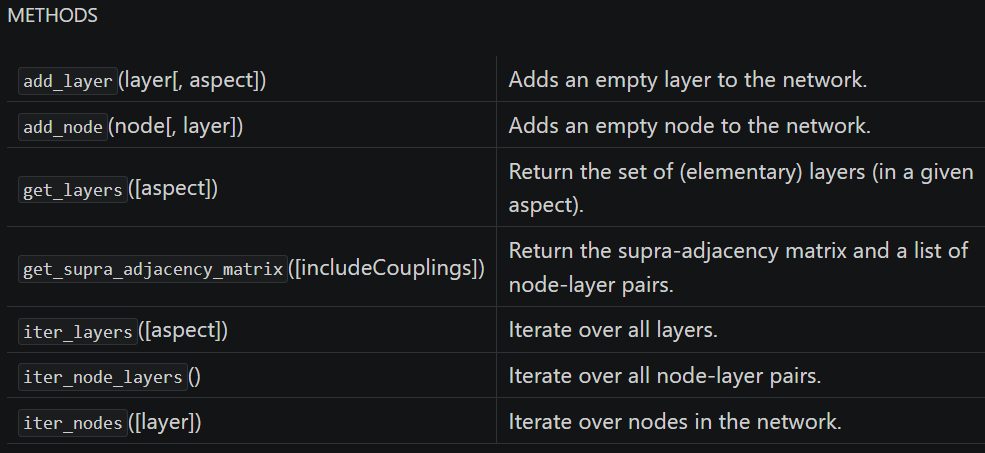

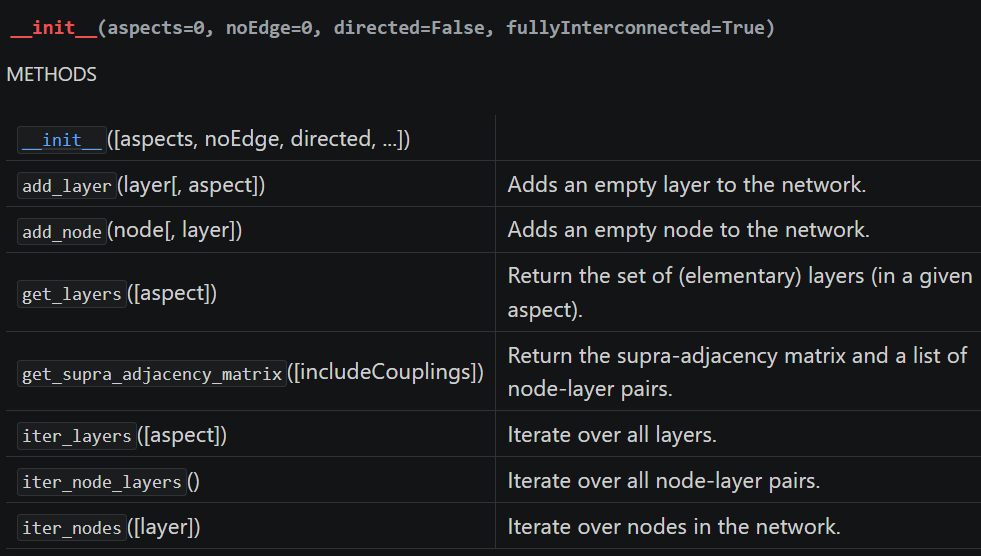

In [ ]:
#Crear red multicapa
mnet = pymnet.MultilayerNetwork(aspects=1)

#Añadir nodo
mnet.add_node(1)
#Añadir capa
mnet.add_layer("a")

Ahora necesitaremos el nodo y la capa para acceder a un nodo

In [ ]:
mnet[1, "a"].deg()

0

Para definir enlaces en redes con 1 aspecto, en este caso, es un enlace intercapa, pues conecta el nodo 1 de la capa "a" con el nodo 2 de la capa "b".

In [ ]:
mnet[1, 2, "a", "b"] = 1

In [ ]:
mnet[1, "a"][2, "b"] = 1

In [ ]:
#Enlaces del nodo 1 de la capa "a" (pues puede haber un nodo 1 en la capa "b")
list(mnet[1, "a"])

[(2, 'b')]

In [ ]:
list(mnet)

[1, 2]

## Ejercicio:
Crear una red con 2 capas:
* ausentes
* presentes

Nodos:
* alumnos

Enlaces:
* si platican entre ustedes

In [9]:
m_alumnnos = pymnet.MultilayerNetwork(aspects=1)

In [16]:

#Añadir capas
m_alumnnos.add_layer(0)
m_alumnnos.add_layer(1)
#Añadir nodos
#m_alumnnos.add_node(["Kimberly",1], ["Adan",1], ["Saul",1], ["Benjamin",1],
                    #["Luis",0],["Fernando",0],["Omar",0])
m_alumnnos.add_node("Kimberly", 1)
m_alumnnos.add_node("Adan",1)
#Añadir enlaces
m_alumnnos["Kimberly", 1]["Adan",1] = 1

In [17]:
m_alumnnos["Kimberly", 1]["Adan",1]

1

Generalizando aspectos

In [18]:
#Creamos una red con 2 aspectos
mnet2 = pymnet.MultilayerNetwork(aspects=2)

mnet2[1, 2, "a" ,"b", "x" ,"y"] = 1
mnet2[1, "a", "x"][2, "b", "y"]

#¿Por qué usar add_layer si se puede declarar desde el aspecto de la capa?
  #Para permitir añadir capas vacías para después
mnet2.add_layer("c", 1)
mnet2.add_layer("z", 2)

In [29]:
mnet2.get_layers(2)

{'x', 'y', 'z'}

In [ ]:
mnet2 = pymnet.MultilayerNetwork(aspects=2)

origen = ("San Lázaro", "MetroBus", "Saturado")
destino = ("San Lázaro", "Metro", "Vacío")

#Un enlace del MB San Lázaro cuyos vagones estan saturados con el Metro San Lázaro el cual tiene vagones vacios
mnet2[origen][destino] = 160 #número de pasajeros

print(mnet2[origen][destino])

160


In [ ]:
##Itera sobre capas combinadas
for layer in mnet2.iter_layers():
    print(layer)

('MetroBus', 'Saturado')
('MetroBus', 'Vacío')
('Metro', 'Saturado')
('Metro', 'Vacío')


# [Visualización](https://mnets.github.io/pymnet/autogen/pymnet.draw.html#pymnet.draw)

In [ ]:
import random
random.seed(42)
import numpy as np
np.random.seed(42)

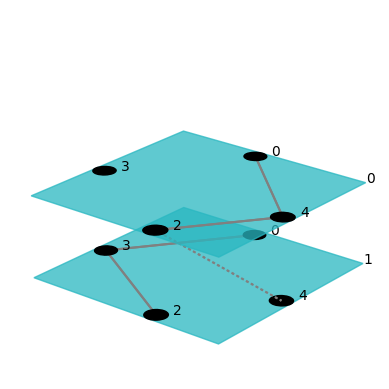

In [30]:
from pymnet import *
#5 nodos, en 2 capas, con 20% de probabilidad de enlace (entre todos los nodos, intracapa e intercapa)
net = models.er_multilayer(5, 2, 0.2)
fig = draw(net) #En colab se muestra en automatico, en .py se necesita el argumento: show=True

Erdos-Renyi multiplex

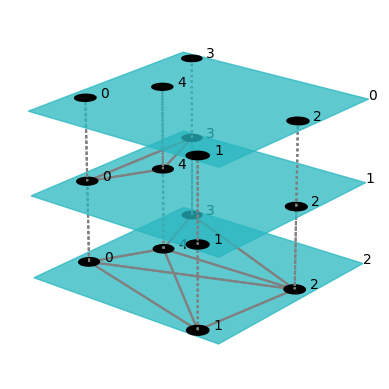

In [31]:
#Una red con 3 capas, 5 nodos, cada capa con cierta probabilidad de enlace
fig = draw(er(5, [0.1,0.35,0.8]), layout="spring")

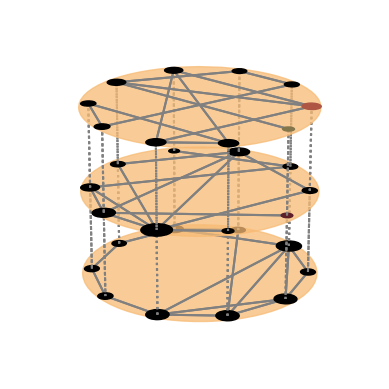

In [ ]:
fig = draw(er(10, 3*[0.3]),
           #Posición de nodos
           layout="circular",
           #Forma de las capas
           layershape="circle",
           layerColorDict={0: "#f7bb75", 1: "#f7bb75", 2: "#f7bb75"},
           #Color de los nodos (capa superior pequeña ,capa superior grande, capa del medio)
           nodeColorDict={(0,0):"#83764c", (1,0):"#ae5543", (0,1):"#5e1f28"},
           layerLabelRule={},
           nodeLabelRule={},
           nodeSizeRule={"rule":"degree", "propscale":0.05}
           )

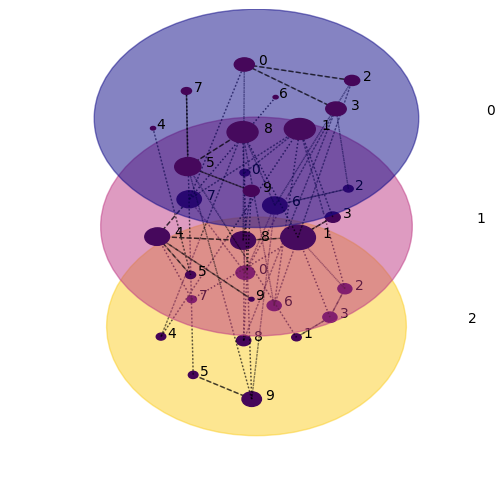

In [40]:
from pymnet import *
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

#Red Erdos-Renyi
net = models.er_multilayer(10, 3, 0.15)

#Diccionario para las capas
layers = list(net.get_layers())
colors = [cm.plasma(i) for i in np.linspace(0, 0.9, len(layers))]
my_layer_colors = dict(zip(layers, colors))

#Visualización
fig = draw(net,
           layout='spring', #Se alejan como resorte
           layershape='circle', #o rectangle
           azim=-45, #ángulo de rotación horizontal de la cámara alrededor de la red.
           elev=45, #qué tan arriba o abajo estás respecto al horizonte (si miras la red desde el techo o a nivel del suelo).
           layergap=1.25, #distancia entre las capas
           autoscale=True,

           #Capas
           layerColorDict=my_layer_colors, #Color de las capas
           defaultLayerAlpha=0.5, #Transparencia de las capas
           layerPadding=0.5, #Espaciado entre los nodos y el borde de cada capa

           #Nodos
           #Para el tamaño y color de nodos, 'degree' suele ser seguro
           nodeColorRule={'rule': 'degree', 'colormap': 'viridis'}, #no hay documentacion, pero puede ser una lista de colores o por colormap
           nodeSizeRule={'rule': 'degree', 'propscale': 0.05}, #Tamaño de los nodos relativo a su grado
           nodeLabelRule={'rule': 'nodename'}, #Nombre de los nodos visual

           #Aristas
           #'edgetype' permite estilos distintos para intra e inter capa
           edgeStyleRule={'rule': 'edgetype', 'intra': '--', 'inter': ':'}, #'-', '--', '-.', ':'
           edgeColorRule={'rule': 'edgeweight', 'colormap': 'magma'}, #grosor de enlaces y color
           defaultEdgeAlpha=0.5, #transparencia de enlaces
           defaultEdgeWidth=1.0 #grosor de enlaces
)

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

# Isomorfismos y Automorfismos

In [ ]:
#Red social (Alice, Bob y Carol)
net_social = MultiplexNetwork(couplings="categorical", fullyInterconnected=False)
net_social["Alice", "Bob", "Friends"] = 1
net_social["Alice", "Carol", "Friends"] = 1
net_social["Bob", "Carol", "Friends"] = 1
net_social["Alice", "Bob", "Married"] = 1

#Red de transporte (Helsinki, Turku y Tampere)
net_transport = MultiplexNetwork(couplings="categorical", fullyInterconnected=False)
net_transport["Helsinki", "Turku", "Train"] = 1
net_transport["Helsinki", "Tampere", "Train"] = 1
net_transport["Turku", "Tampere", "Train"] = 1
net_transport["Helsinki", "Turku", "Ferry"] = 1

In [ ]:
#Aspects = 0 solo permite cambiar el nombre de los nodos
print(is_isomorphic(net_social, net_transport, allowed_aspects=[0]))

False


Porque las capas "Friends"/"Married" no coinciden con "Train"/"Ferry"

In [ ]:
#Aspects = 1 solo permite cambiar el nombre de las capas
print(is_isomorphic(net_social, net_transport, allowed_aspects=[1]))

False


Porque los nombres de los nodos no coinciden, solo el de las capas

In [ ]:
#¿Son iguales si podemos cambiar nombres de nodos Y de capas?
print(is_isomorphic(net_social, net_transport, allowed_aspects=[0, 1]))

True


In [ ]:
#Saber el mapeo de los nodos que permite construir la misma red
print(get_isomorphism(net_social, net_transport))

[{'Bob': 'Helsinki', 'Alice': 'Turku', 'Carol': 'Tampere'}, {'Married': 'Ferry', 'Friends': 'Train'}]
